# TOPIC MODELING - LDA (Latent Dirichlet Allocation)

**Input**: Hasil analisis sentimen (13.192 data, no-stem, SLA + Ignore Function)  
**Target**: Data sentimen negatif  
**Metode**: LDA via Gensim  

**Referensi utama**:
- Gensim LDA: https://radimrehurek.com/gensim/models/ldamodel.html
- Gensim Dictionary & Corpus: https://radimrehurek.com/gensim/corpora/dictionary.html
- CoherenceModel (C_v): Röder et al. (2015) https://github.com/dice-group/Palmetto
- pyLDAvis: Sievert & Shirley (2014) https://github.com/bmabey/pyLDAvis
- Contoh pipeline LDA dengan Gensim: https://github.com/RaRe-Technologies/gensim/blob/develop/docs/notebooks/lda_training_tips.ipynb

In [1]:
# 1. Instalasi Library yang Diperlukan

import sys
import importlib

# Daftar library yang diperlukan untuk pipeline LDA
required_packages = ['gensim', 'pyLDAvis', 'nltk']

for package in required_packages:
    try:
        importlib.import_module(package)
        print(f"{package} sudah terinstall.")
    except ImportError:
        print(f"Menginstall {package}...")
        !{sys.executable} -m pip install {package}
        print(f"{package} berhasil diinstall.")

gensim sudah terinstall.
pyLDAvis sudah terinstall.
nltk sudah terinstall.


In [2]:
# 2. Import Library

import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
# 3. Load Data Sentimen Negatif
# note: Input: hasil analisis sentimen 13.192 data (pendekatan ISV-SLA, perlakuan Ignore Function, versi no-stem).
df = pd.read_csv('../sentiment-analysis-final/outputs/sentiment_clean.csv')

df_neg = df[df['sentiment'] == 'negative'].copy().reset_index(drop=True)

print("Total data sentimen negatif:", len(df_neg))
df_neg.head()

Total data sentimen negatif: 4854


,no,timestamp,teks,teks_processed,sentiment,compound_score
0,2,2016-12-30T06:30:36.000Z,Tertibkan Media Online DPR Pemerintah Jangan S...,tertibkan media online DPR pemerintah jangan s...,negative,-0.862736
1,3,2016-12-30T04:48:35.000Z,harus dievaluasi lg kebijakan bebas visa truta...,harus dievaluasi lagi kebijakan bebas visa ter...,negative,-0.874530
2,4,2016-12-30T04:21:40.000Z,jangan ngambang aturan logis apa undang undang,jangan ngambang aturan logis apa undang undang,negative,-0.526742
3,5,2016-12-30T02:36:13.000Z,Kebebasan bersuara berpendapat memang dijamin ...,kebebasan bersuara berpendapat memang dijamin ...,negative,-0.655311
4,6,2016-12-30T02:52:25.000Z,Anggota Komisi IX DPR Okky Asokawati Evaluasi ...,anggota komisi IX DPR okky asokawati evaluasi ...,negative,-0.368037


In [ ]:
# 4. Preprocessing Tambahan untuk LDA

stop_words = set(stopwords.words('indonesian'))

# Stopword tambahan: entitas domain, noise sosial media, dan sufiks yang lolos tokenisasi
custom_stopwords = {
    'rt', 'via', 'twitter', 'x',
    'dpr', 'ri', 'dpri', 'dprri',
    'anggota', 'rapat', 'paripurna', 'ruu', 'uu',
    'pak', 'bu', 'gan', 'sis', 'min',
    'nya', 'kan', 'lah', 'kah',
}
stop_words.update(custom_stopwords)

def preprocess_for_lda(text):
    """
    Preprocessing minimal untuk LDA di atas teks yang sudah dinormalisasi.
    Lowercase, filter non-alfabet, stopword removal, dan filter panjang token.
    """
    if not isinstance(text, str):
        return []
    tokens = text.lower().split()
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
    return tokens

df_neg['tokens_lda'] = df_neg['teks_processed'].apply(preprocess_for_lda)

# Filter dokumen yang terlalu pendek setelah cleaning
doc_lengths = df_neg['tokens_lda'].apply(len)
df_neg = df_neg[doc_lengths >= 5].reset_index(drop=True)

print("Dokumen valid untuk LDA:", len(df_neg))

Dokumen valid untuk LDA: 4378


Data `teks_processed` sudah melalui noise removal, word lengthening normalization, slang normalization, dan tokenisasi di tahap sebelumnya.

Preprocessing tambahan di sini hanya untuk kebutuhan teknis LDA:
- **Stopword removal**: kata fungsi tidak membawa informasi topik dan akan mendominasi distribusi kata secara artifisial
- **Filter panjang token**: buang token ≤ 2 karakter (sisa noise atau sufiks)
- **Lowercase**: agar variasi kapitalisasi dihitung sebagai kata yang sama

Referensi penerapan filter ini: https://radimrehurek.com/gensim/corpora/dictionary.html#gensim.corpora.dictionary.Dictionary.filter_extremes

In [ ]:
# 5. Dictionary dan Corpus (Bag-of-Words)

dictionary = corpora.Dictionary(df_neg['tokens_lda'])

# Hapus kata yang muncul di < 5 dokumen atau > 50% dokumen
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(tokens) for tokens in df_neg['tokens_lda']]

print("Vocabulary size :", len(dictionary))
print("Corpus size     :", len(corpus))

Vocabulary size : 1639
Corpus size     : 4378


Referensi: https://radimrehurek.com/gensim/corpora/dictionary.html

`filter_extremes`: menghapus kata yang terlalu jarang (`no_below`) atau terlalu umum (`no_above`) agar tidak mendominasi topik secara statistik.

In [ ]:
# 6. Menentukan Jumlah Topik Optimal (Grid Search via Coherence Score)

k_values = range(3, 16)
coherence_scores = []
models = {}

for k in k_values:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        iterations=100
    )
    cm = CoherenceModel(
        model=model,
        texts=df_neg['tokens_lda'],
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    models[k] = model
    print(f"k={k:2d} | Coherence (C_v): {score:.4f}")

best_k = list(k_values)[np.argmax(coherence_scores)]
print(f"\nJumlah topik optimal: k = {best_k} (Coherence: {max(coherence_scores):.4f})")

k= 3 | Coherence (C_v): 0.2993
k= 4 | Coherence (C_v): 0.2821
k= 5 | Coherence (C_v): 0.3254
k= 6 | Coherence (C_v): 0.3096
k= 7 | Coherence (C_v): 0.3286
k= 8 | Coherence (C_v): 0.3584
k= 9 | Coherence (C_v): 0.3439
k=10 | Coherence (C_v): 0.3664
k=11 | Coherence (C_v): 0.3612
k=12 | Coherence (C_v): 0.3762
k=13 | Coherence (C_v): 0.3965
k=14 | Coherence (C_v): 0.3869
k=15 | Coherence (C_v): 0.3696

Jumlah topik optimal: k = 13 (Coherence: 0.3965)


Menggunakan metrik **C_v coherence** yang direkomendasikan oleh Röder et al. (2015) sebagai metrik evaluasi kualitas topik yang paling berkorelasi dengan penilaian manusia.

Referensi:
- Röder et al. (2015): http://svn.aksw.org/papers/2015/WSDM_Topic_Evaluation/public.pdf
- CoherenceModel Gensim: https://radimrehurek.com/gensim/models/coherencemodel.html
- Contoh grid search: https://github.com/RaRe-Technologies/gensim/blob/develop/docs/notebooks/lda_training_tips.ipynb

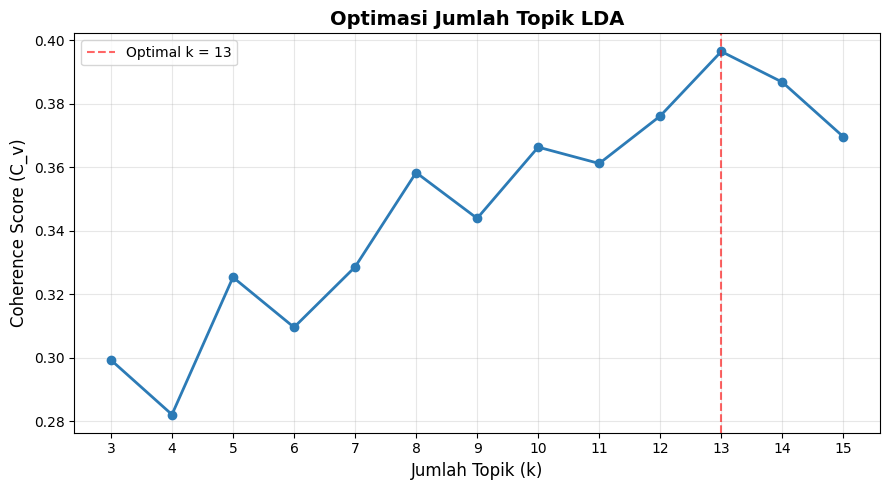

Grafik disimpan: lda_coherence_optimization.png


In [ ]:
# 7. Visualisasi Coherence Score
plt.figure(figsize=(9, 5))
plt.plot(list(k_values), coherence_scores, marker='o', linestyle='-', color='#2c7bb6', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Optimal k = {best_k}')
plt.xlabel('Jumlah Topik (k)', fontsize=12)
plt.ylabel('Coherence Score (C_v)', fontsize=12)
plt.title('Optimasi Jumlah Topik LDA', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig('lda_coherence_optimization.png', dpi=300)
plt.show()
print("Grafik disimpan: lda_coherence_optimization.png")

In [ ]:
# 8. Model LDA Final

# Latih ulang model final dengan passes lebih tinggi
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=15,
    iterations=150,
    alpha='auto',
    eta='auto'
)

# Evaluasi perplexity model final
perplexity = lda_model.log_perplexity(corpus)
print(f"Log Perplexity : {perplexity:.4f}")

cm_final = CoherenceModel(
    model=lda_model,
    texts=df_neg['tokens_lda'],
    dictionary=dictionary,
    coherence='c_v'
)
print(f"Coherence (C_v): {cm_final.get_coherence():.4f}")

Log Perplexity : -6.7589
Coherence (C_v): 0.4090


Menggunakan model terbaik dari grid search (tidak dilatih ulang).

Parameter `passes=15, iterations=150` untuk konvergensi lebih baik pada model final.  
Parameter `alpha='auto', eta='auto'` menggunakan expectation-maximization untuk menyesuaikan hyperparameter secara otomatis.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html

In [ ]:
# 9. Ekstraksi Kata Kunci per Topik

topics_data = []

print("Top 10 Kata Kunci per Topik:\n")
for idx in range(lda_model.num_topics):
    top_words = lda_model.show_topic(idx, topn=10)
    words = [(word, round(prob, 4)) for word, prob in top_words]
    word_list = [w for w, _ in words]
    print(f"Topik {idx:2d}: {' | '.join(word_list)}")
    topics_data.append({
        'topic_id': idx,
        'top_words': ', '.join(word_list),
        'top_words_with_prob': str(words)
    })

topics_df = pd.DataFrame(topics_data)
topics_df.to_csv('lda_topics_keywords.csv', index=False)
print("\nDisimpan: lda_topics_keywords.csv")

Top 10 Kata Kunci per Topik:

Topik  0: pemilu | pdip | kekerasan | menolak | seksual | parpol | mengesahkan | polisi | penghapusan | pansus
Topik  1: koruptor | mati | rieke | kebijakan | hukuman | diah | pitaloka | khusus | gubernur | indonesia
Topik  2: fraksi | pks | ketua | partai | puan | titik | persen | the | tpks | maharani
Topik  3: ppn | pajak | komisi | tau | menteri | nasional | keuangan | menolak | apbn | nama
Topik  4: bikin | kebijakan | prabowo | aneh | kepentingan | tugasnya | malu | pengesahan | janji | wacana
Topik  5: dewan | daerah | perwakilan | rakyat | dprd | sidang | jakarta | kota | reses | menggelar
Topik  6: reses | komisi | kerja | kunjungan | anggaran | selatan | dapil | kali | ketua | terkait
Topik  7: undang | presiden | komisi | rancangan | orang | revisi | partai | sumatera | anies | nomor
Topik  8: hadir | bpk | dana | pembahasan | mengkritik | disetujui | bilang | kosong | tni | diajukan
Topik  9: kebijakan | pemerintah | masyarakat | kenaikan | neg

Menggunakan `show_topic()` untuk ekstraksi yang lebih aman dibanding parsing string `print_topics()`.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html#gensim.models.ldamodel.LdaModel.show_topic

pyLDAvis memvisualisasikan jarak antar topik (via PCoA) dan distribusi kata per topik.

Referensi: Sievert & Shirley (2014) — https://github.com/bmabey/pyLDAvis  
Paper: https://aclanthology.org/W14-3110/

In [ ]:
# 10. Visualisasi Interaktif pyLDAvis

vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis_data, 'lda_visualization.html')
print("Disimpan: lda_visualization.html")

pyLDAvis.display(vis_data)

Disimpan: lda_visualization.html


In [ ]:
# 11. Assign Topik Dominan per Dokumen

doc_topics = lda_model.get_document_topics(corpus, minimum_probability=0.0)

dominant_topics = []
topic_probs = []

for doc in doc_topics:
    topic_dist = dict(doc)
    dominant = max(topic_dist, key=topic_dist.get)
    dominant_topics.append(dominant)
    topic_probs.append(round(topic_dist[dominant], 4))

df_neg['dominant_topic'] = dominant_topics
df_neg['topic_probability'] = topic_probs

# Simpan tanpa kolom list/dict agar kompatibel dengan CSV
cols_to_save = [c for c in df_neg.columns if c != 'tokens_lda']
df_neg[cols_to_save].to_csv('lda_negative_results.csv', index=False)

print("Disimpan: lda_negative_results.csv")
df_neg[['teks_processed', 'dominant_topic', 'topic_probability']].head(10)

Disimpan: lda_negative_results.csv


,teks_processed,dominant_topic,topic_probability
0,tertibkan media online DPR pemerintah jangan s...,12,0.5473
1,harus dievaluasi lagi kebijakan bebas visa ter...,9,0.5919
2,jangan ngambang aturan logis apa undang undang,7,0.6578
3,kebebasan bersuara berpendapat memang dijamin ...,12,0.6616
4,anggota komisi IX DPR okky asokawati evaluasi ...,9,0.6262
5,wapres meminta kebijakan bebas visa dievaluasi...,9,0.7837
6,ketua panja RUU revisi ITE TB hasanuddin sampa...,7,0.4559
7,berdasarkan tatib DPR pasal ayat hasil reses t...,7,0.3878
8,pada masa reses DPR melaksanakan tugas menyera...,10,0.4039
9,masa reses sendiri tertuang dalam UU MD no dan...,9,0.4816


Setiap dokumen memiliki distribusi probabilitas terhadap semua topik.  
Topik dominan adalah topik dengan probabilitas tertinggi untuk dokumen tersebut.

Referensi: https://radimrehurek.com/gensim/models/ldamodel.html#gensim.models.ldamodel.LdaModel.get_document_topics

 topic_id  jumlah_dokumen  persentase
        0             374        8.54
        1             203        4.64
        2             249        5.69
        3             180        4.11
        4             192        4.39
        5             351        8.02
        6             377        8.61
        7             364        8.31
        8             121        2.76
        9             816       18.64
       10             667       15.24
       11             286        6.53
       12             198        4.52


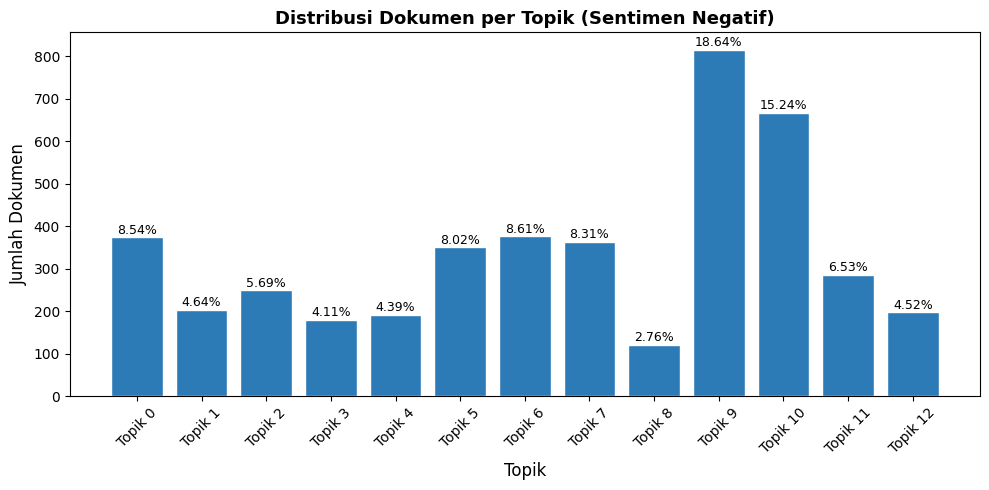

Disimpan: lda_topic_distribution.png


In [ ]:
# 12. Distribusi Dokumen per Topik

topic_counts = df_neg['dominant_topic'].value_counts().sort_index()
topic_pct = (topic_counts / len(df_neg) * 100).round(2)

dist_df = pd.DataFrame({
    'topic_id': topic_counts.index,
    'jumlah_dokumen': topic_counts.values,
    'persentase': topic_pct.values
})

print(dist_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [f'Topik {i}' for i in topic_counts.index],
    topic_counts.values,
    color='#2c7bb6',
    edgecolor='white'
)
for bar, pct in zip(bars, topic_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{pct}%',
        ha='center', va='bottom', fontsize=9
    )
ax.set_xlabel('Topik', fontsize=12)
ax.set_ylabel('Jumlah Dokumen', fontsize=12)
ax.set_title('Distribusi Dokumen per Topik (Sentimen Negatif)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=45 if best_k > 8 else 0)
plt.tight_layout()
plt.savefig('lda_topic_distribution.png', dpi=300)
plt.show()
print("Disimpan: lda_topic_distribution.png")

## Ringkasan Output

| File | Deskripsi |
|---|---|
| `lda_coherence_optimization.png` | Grafik coherence score per jumlah topik |
| `lda_topics_keywords.csv` | Kata kunci top-10 per topik |
| `lda_visualization.html` | Visualisasi interaktif pyLDAvis |
| `lda_negative_results.csv` | Data negatif + label topik dominan |
| `lda_topic_distribution.png` | Grafik distribusi dokumen per topik |